# Thalweg for PBDEs concentration along the strait

In [1]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as NC
import itertools
from matplotlib import pylab
import sys 

#
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
def find_thalweg(bathy,ist,jst,direction,ijend,thres):
    #Starting at (ist,jst) this function computes the gridpoints of thalweg by iterating through points until ijend.
    #At each iteration it calculates the maximum depth in a neighborhood of (i,j)
    #bathy: an array of the bathymetry
    #ist: an int that defines the starting i grid point
    #jst: an int that defines the starting j grid point
    #direction: a string either 'i' or 'j' indicating the direction of the iterations
    #thres: an int defining the size of the neighbourhood.
    
    #returns thalweg: an array contatining the [j,i] thalweg gridpoints.
    
    if direction == 'i':
    
        #thres defines the search distance in the i-direction.
        if ist<ijend:
            thalweg=np.zeros((ijend-ist,2))
            loop_start=ist+1; loop_end=ijend
            forward=1; backward=0
        else:
            thalweg=np.zeros((ist-ijend,2)) 
            loop_start=0; loop_end=ist-ijend-1;
            forward=0; backward=1;
    
        #find index of first maximum
        bathmax=bathy[jst-thres:jst+thres,ist].max(); 
        ind= np.where(bathy[:,ist]==bathmax)
        ls=0
        while ind[0][ls]< jst-thres:
            ls=ls+1
        j=ind[0][ls]
        arr_ind=0*forward + (ist-ijend-1)*backward;  
        thalweg[arr_ind,0]=j
        thalweg[arr_ind,1]=ist

        #for loop for finding the thalweg
        for k in range (loop_start,loop_end):
            loop_ind = k*forward + (ist-k)*backward;
            bathmax=bathy[j-thres:j+thres,loop_ind].max();
            ind= np.where(bathy[:,loop_ind]==bathmax)
            ls=0
            while ind[0][ls]< j-thres:
                ls=ls+1
            j=ind[0][ls]
            arr_ind=(k-ist)*forward + (loop_end-k-1)*backward;  
            thalweg[arr_ind,0]=j
            thalweg[arr_ind,1]=loop_ind;
            
    elif direction == 'j':
    
        #thres defines the search distance in the j-direction.
        if jst<ijend:
            thalweg=np.zeros((ijend-jst,2))
            loop_start=jst+1; loop_end=ijend
            forward=1; backward=0
        else:
            thalweg=np.zeros((jst-ijend,2)) 
            loop_start=0; loop_end=jst-ijend-1;
            forward=0; backward=1;
    
        #find index of first maximum
        bathmax=bathy[jst,ist-thres:ist+thres].max(); 
        ind= np.where(bathy[jst,:]==bathmax)
        ls=0
        while ind[0][ls]< ist-thres:
            ls=ls+1
        i=ind[0][ls]
        arr_ind=0*forward + (jst-ijend-1)*backward;  
        thalweg[arr_ind,0]=jst
        thalweg[arr_ind,1]=i

        #for loop for finding the thalweg
        for k in range (loop_start,loop_end):
            loop_ind = k*forward + (jst-k)*backward;
            bathmax=bathy[loop_ind,i-thres:i+thres].max();
            ind= np.where(bathy[loop_ind,:]==bathmax)
            ls=0
            while ind[0][ls]< i-thres:
                ls=ls+1
            i=ind[0][ls]
            arr_ind=(k-jst)*forward + (loop_end-k-1)*backward;  
            thalweg[arr_ind,0]=loop_ind
            thalweg[arr_ind,1]=i;
            
    else:
        return 'Error'
    
    return thalweg

In [3]:
def distance(thalweg,dx,dy):
    #this function calculates the distance travelled along the thalweg
    #thalweg is the array of grid coordinates.
    #dx is the grid spacing in x (eventually we could send an array in but for now it is a single value).
    #dy is the grid spacing in y (eventually we could send an array in but for now it is a single value).
    
    leng=thalweg.shape
    l =leng[0]
    distance = np.zeros(l)
    d=0
    
    for k in range(1,l):
        i1=thalweg[k-1,1]; i2=thalweg[k,1];
        j1=thalweg[k-1,0]; j2=thalweg[k,0];
        dseg =( (dx*(i2-i1))**2 + (dy*(j2-j1))**2)**(0.5)
        d=d+dseg
        distance[k]=d;

    return distance

In [4]:
def remove_section(thalweg, start, end, direction):
    #This function is used to remove a jagged section of the thalweg and replace it with a straight line.
    #thalweg: an array containing the thalweg grid coordinates
    #start: an int containing the i or j coordintate where the cut begins
    #end: an int contatining the i o j coordinate where the cut ends
    #direction: indicates where start and end represent an i or j coordinate.

    if direction == 'j':
        flag1=0; flag2=1
    elif direction == 'i':
        flag1=1; flag2=0
    else:
        return 'Error'
        
    #find index of cut points in other coordinate
    index= np.where(thalweg[:,flag1]==start); index_st=index[0][0]
    index= np.where(thalweg[:,flag1]==end); index_end=index[0][0]

    #start and end points of
    start2=thalweg[index_st,flag2]; end2=thalweg[index_end,flag2]; 
    #draw a straight line to connect (start,start2) to (end,end2)
    newinds = start2 + (end2-start2)/(end-start)*(thalweg[index_st:index_end,flag1]-start)
    newinds=np.rint(newinds)
    #replace the thalwegs with newinds
    thalweg_copy=thalweg
    thalweg_copy[index_st:index_end,flag2] = newinds
    
    return thalweg_copy

103 321
203 251
244 326
276 378
255 476
169 576


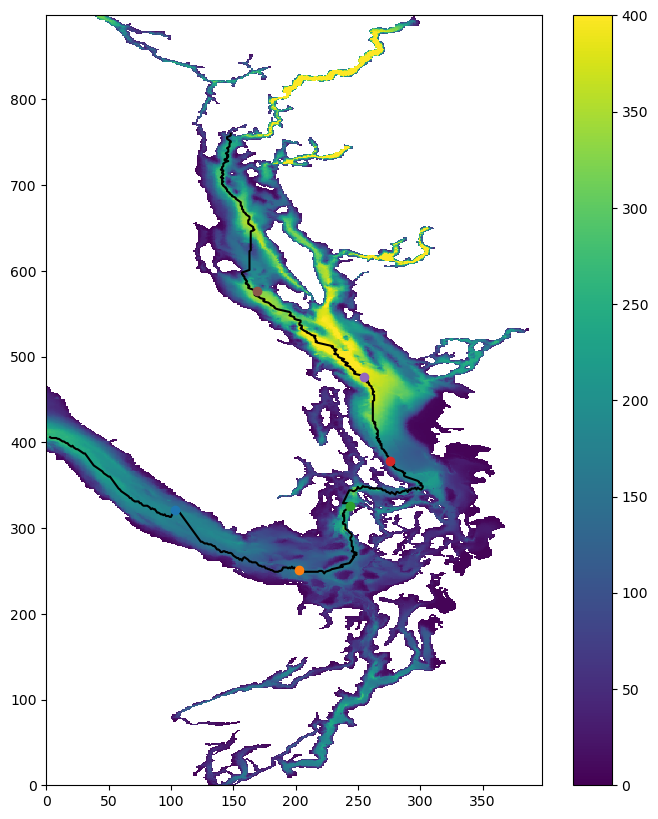

In [5]:
# test the function
grid = NC.Dataset('/data/nsoontie/MEOPAR/NEMO-forcing/grid/bathy_meter_SalishSea.nc','r')
bathy = grid.variables['Bathymetry'][:,:]

#masking
mu =bathy == 0
bathy_mask= np.ma.array(bathy,mask=mu)

#the thalweg is caclualted in sections:
#caculate first section of thalweg
step=3; ist=264; jst=415; ijend=760; direction = 'j';
thalweg5 = find_thalweg(bathy,ist,jst,direction,ijend,step)
#remove several jagged sections
jstart=600; jend=645;
thalweg5 = remove_section(thalweg5,jstart,jend,'j');
jstart=425; jend=447;
thalweg5 = remove_section(thalweg5,jstart,jend,'j');
#next section
jst=int(thalweg5[0,0]);  ist= int(thalweg5[0,1]); ijend=346; direction='j';
thalweg4 = find_thalweg(bathy,ist,jst,direction,ijend,step)
#next section
jst=int(thalweg4[0,0]);  ist= int(thalweg4[0,1]); ijend=235; direction='i';
thalweg3 = find_thalweg(bathy,ist,jst,direction,ijend,step)
#next section
jst=int(thalweg3[0,0]);  ist= int(thalweg3[0,1]); ijend=246; direction='j';
thalweg2 = find_thalweg(bathy,ist,jst,direction,ijend,step)
#next section
jst=int(thalweg2[0,0]);  ist= int(thalweg2[0,1]); ijend=0; direction='i';
thalweg1 = find_thalweg(bathy,ist,jst,direction,ijend,step)

#Combine all together
Tjs = [thalweg1[:,0],thalweg2[:,0],thalweg3[:,0],thalweg4[:,0],thalweg5[:,0]];
Tjs =list(itertools.chain.from_iterable(Tjs)); Tjs=np.array(Tjs); 
Tis = [thalweg1[:,1],thalweg2[:,1],thalweg3[:,1],thalweg4[:,1],thalweg5[:,1]];
Tis =list(itertools.chain.from_iterable(Tis)); Tis=np.array(Tis); 

thalweg=[Tjs, Tis];  thalweg=list(zip(*thalweg)); thalweg=np.array(thalweg,'i'); 

plt.figure(figsize=(8,10))
cmin=0; cmax=400;
pylab.pcolormesh(bathy,vmin=cmin,vmax=cmax)
pylab.colorbar()

pylab.plot(thalweg[:,1]+1,thalweg[:,0]+1,color='k')

for k in range (1,7):
    pylab.plot(thalweg[k*100,1]+1, thalweg[k*100,0]+1,'o')
    print(thalweg[k*100,1] + 1, thalweg[k*100,0] + 1)

#pylab.axis([240,300,300,400])

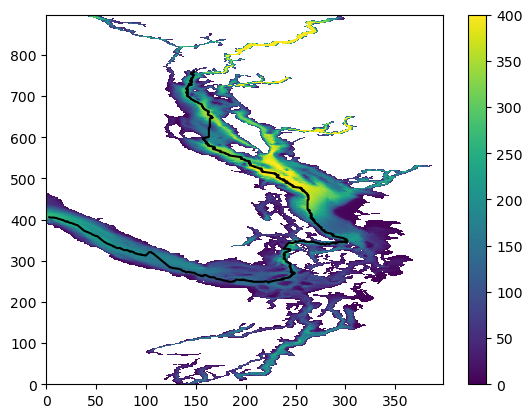

In [6]:
plt.pcolormesh(bathy_mask, vmin = 0, vmax = 400)
plt.plot(thalweg[:,1]+1,thalweg[:,0]+1,color='k')

plt.colorbar()

In [7]:
np.savetxt("my_thalweg.txt", thalweg,fmt="%.0f", delimiter=" ")

Text(0, 0.5, ' z (m)')

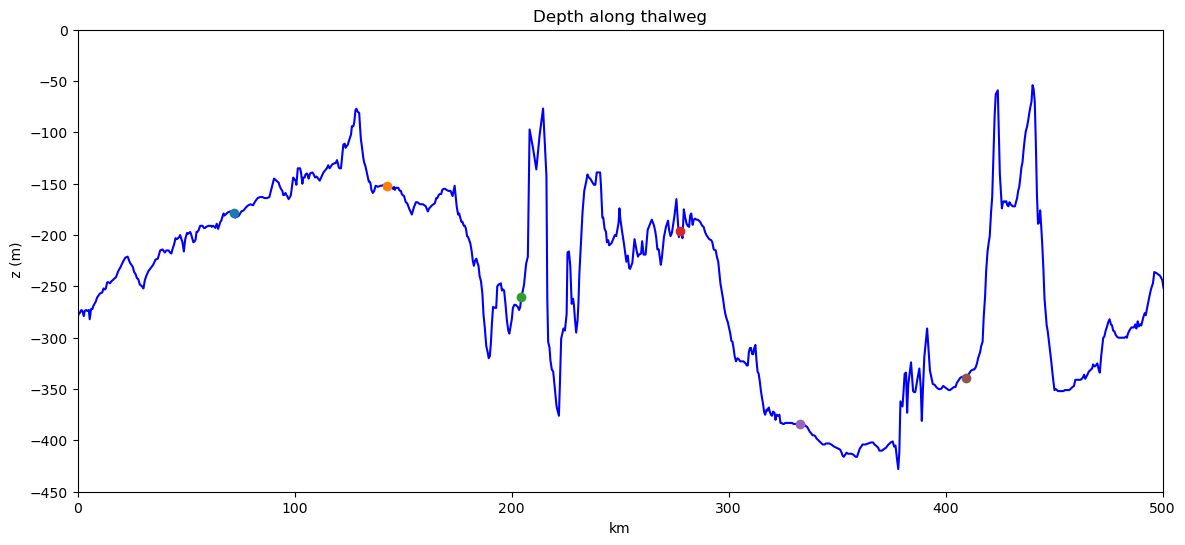

In [8]:
#look at the depths along the thalweg
ax=[0,500,-450,0]

depths = bathy[thalweg[:,0],thalweg[:,1]];
dx=400; dy=500
d = distance(thalweg,dx,dy); d=d/1000;

plt.figure(figsize=(14,6))
pylab.plot(d,-depths[:],color='b')
for k in range (1,7):
    pylab.plot(d[k*100], -depths[k*100],'o')
    
pylab.title('Depth along thalweg')
pylab.axis(ax)
pylab.xlabel('km')
pylab.ylabel(' z (m)')

In [9]:
#plot a salinity field along the thalweg
f = NC.Dataset('/results2/SalishSea/nowcast-green.202111/13dec07/SalishSea_1h_20071213_20071213_grid_T.nc','r');
sal = f.variables['vosaline']
salPlot=sal[0,:,:,:];
smin=28; smax=34
dep = f.variables['deptht']

vs=np.arange(34,27.5,-0.5);

salThalweg=salPlot[:,thalweg[:,0],thalweg[:,1]];


Text(0, 0.5, ' z (m)')

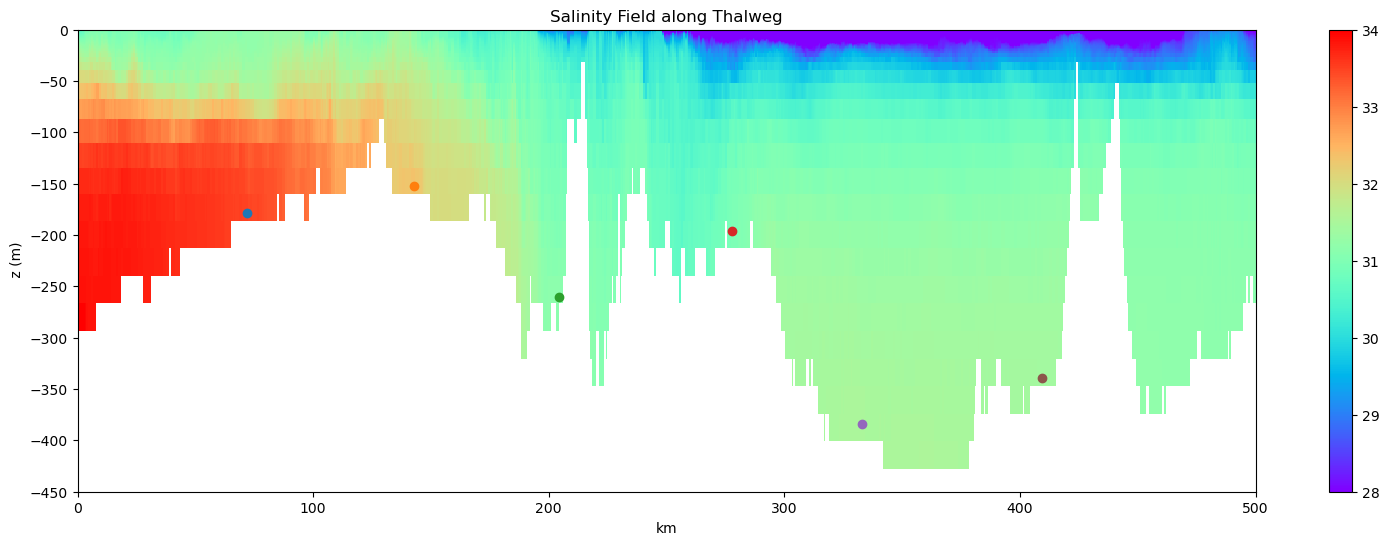

In [10]:

#masking
mu =salThalweg == 0
salThalweg= np.ma.array(salThalweg,mask=mu)
XX,ZZ = np.meshgrid(d,-dep[:])

plt.figure(figsize=(19,6))
pylab.pcolormesh(XX,ZZ,salThalweg,vmin=smin,vmax=smax,cmap='rainbow')
pylab.colorbar()
#CS=pylab.contour(XX,ZZ,salThalweg,vs, colors='black')

#pylab.clabel(CS, fontsize=9, inline=1)

for k in range (1,7):
    pylab.plot(d[k*100], -depths[k*100],'o')
    
#pylab.axis(ax)
pylab.title('Salinity Field along Thalweg')
pylab.axis(ax)
pylab.xlabel('km')
pylab.ylabel(' z (m)')

# Let's try with PBDEs now

In [11]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V2_year_2.nc'
#filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/RESTART_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added_restart_365_days_no_release_1_year.zarr'

In [12]:
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
#
data = xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep])
#data2 = xr.open_dataset(filename2, engine = 'zarr', drop_variables=[v for v in xr.open_dataset(filename2, engine = 'zarr').variables if v not in vars_to_keep])

In [13]:
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [14]:
x = np.linspace(0,397,398)
y = np.linspace(0,897,898)
X, Y =np.meshgrid(x,y)

In [15]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [16]:
import numpy as np
import xarray as xr

def finder2(target_lat, target_lon, mask):
    lat = mask.nav_lat
    lon = mask.nav_lon
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

def particles_amount_dataset_XYDepth(lons, lats, depths, num_depth_bins, mask, num_lon=100, num_lat=100):
#
    #
    lon_edges = np.linspace(mask["nav_lon"].min(), mask["nav_lon"].max(), num_lon + 1)
    lat_edges = np.linspace(mask["nav_lat"].min(), mask["nav_lat"].max(), num_lat + 1)
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    # depth bins
    dmin, dmax = np.nanmin(depths), np.nanmax(depths)
    depth_edges = np.linspace(dmin, dmax, num_depth_bins + 1)
    depth_centers = (depth_edges[:-1] + depth_edges[1:]) / 2

    # 
    concentration = np.zeros((num_depth_bins, num_lat, num_lon), dtype=int)
    ii_sed = np.zeros((num_lat, num_lon), dtype=int)
    jj_sed = np.zeros((num_lat, num_lon), dtype=int)

    # 
    Xedges, Yedges = np.meshgrid(lon_centers, lat_centers)  # 
    for i in range(num_lat):
        for j in range(num_lon):
            jj, ii = finder2(Yedges[i, j], Xedges[i, j], mask)
            ii_sed[i, j] = ii
            jj_sed[i, j] = jj

    #
    for k, (dmin_k, dmax_k) in enumerate(zip(depth_edges[:-1], depth_edges[1:])):
        # 
        depth_mask = (depths >= dmin_k) & (depths < dmax_k)
        lon_sel = lons[depth_mask]
        lat_sel = lats[depth_mask]

        if len(lon_sel) > 0:
            counts, _, _ = np.histogram2d(lon_sel, lat_sel, bins=[lon_edges, lat_edges])
        else:
            counts = np.zeros((num_lon, num_lat))

        concentration[k, :, :] = counts.T  # transpose 

    # 
    ds = xr.Dataset(
        {
            "concentration": (("Depth", "Y", "X"), concentration)
        },
        coords={
            "Depth": ("Depth", depth_centers),
            "Y": (("Y", "X"), ii_sed),
            "X": (("Y", "X"), jj_sed)
        },
        attrs={
            "description": "Particle counts on model grid indices (Depth × Y × X)"
        }
    )

    ds["concentration"].attrs["units"] = "counts per grid cell"
    ds["Depth"].attrs["units"] = "m"

    return ds


In [ ]:
data_thalweg = data

In [ ]:
# Pull the underlying arrays once
status = data_thalweg['status'].values
lon = data_thalweg['lon'].values
lat = data_thalweg['lat'].values
z = data_thalweg['z'].values

# Create boolean indices
idx_sed = status > 10
idx_wat = (status > 0) & (status < 4)

# Extract values directly
lon_sed, lat_sed, depth_sed = lon[idx_sed], lat[idx_sed], z[idx_sed]
lon_wat, lat_wat, depth_wat = lon[idx_wat], lat[idx_wat], z[idx_wat]

In [ ]:
#lon_wat = data_thalweg.where((data_thalweg['status'] > 0) & (data_thalweg['status'] < 4))['lon'].values.flatten()
#lat_wat = data_thalweg.where((data_thalweg['status'] > 0) & (data_thalweg['status'] < 4))['lat'].values.flatten()
#depth_wat = data_thalweg.where((data_thalweg['status'] > 0) & (data_thalweg['status'] < 4))['z'].values.flatten()

In [ ]:
ds = particles_amount_dataset_XYDepth(
    lons=lon_wat,
    lats=lat_wat,
    depths=depth_wat,
    num_depth_bins=40,
    mask=mask,
    num_lon=int(len(x)),
    num_lat=int(len(y)))

In [ ]:
# Flatten the Parcels arrays
lon_flat = data['lon'].values.flatten()
lat_flat = data['lat'].values.flatten()
depth_flat = data['z'].values.flatten()
status_flat = data['status'].values.flatten()

# Ensure your distance array 'd' matches the flattened shape
# (If 'd' was calculated per particle/obs, flatten it as well)
dist_flat = d.flatten() 

# Apply your existing 'water' filter (status 1-3)
idx_wat = (status_flat > 0)

# Filtered arrays for the heatmap
depth_clean = depth_flat[idx_wat]

: 

In [ ]:
def create_dist_depth_heatmap(distances, depths, num_dist_bins=100, num_depth_bins=40):
    # Define bin edges
    dist_edges = np.linspace(np.nanmin(distances), np.nanmax(distances), num_dist_bins + 1)
    depth_edges = np.linspace(np.nanmin(depths), np.nanmax(depths), num_depth_bins + 1)
    
    # Calculate centers for coordinates
    dist_centers = (dist_edges[:-1] + dist_edges[1:]) / 2
    depth_centers = (depth_edges[:-1] + depth_edges[1:]) / 2

    # Bin the data (Histogram counts)
    # This replaces the need for a 3D (Depth, Y, X) dataset
    counts, x_edges, y_edges = np.histogram2d(distances, depths, bins=[dist_edges, depth_edges])

    # Create Xarray Dataset
    ds_heat = xr.Dataset(
        {
            "particle_count": (("distance", "depth"), counts)
        },
        coords={
            "distance": dist_centers,
            "depth": depth_centers
        },
        attrs={"description": "Integrated particle counts along channel axis"}
    )
    
    return ds_heat

# Run the function
ds_heatmap = create_dist_depth_heatmap(np.linspace(np.min(d),np.max(d), len(depth_clean)), depth_clean)

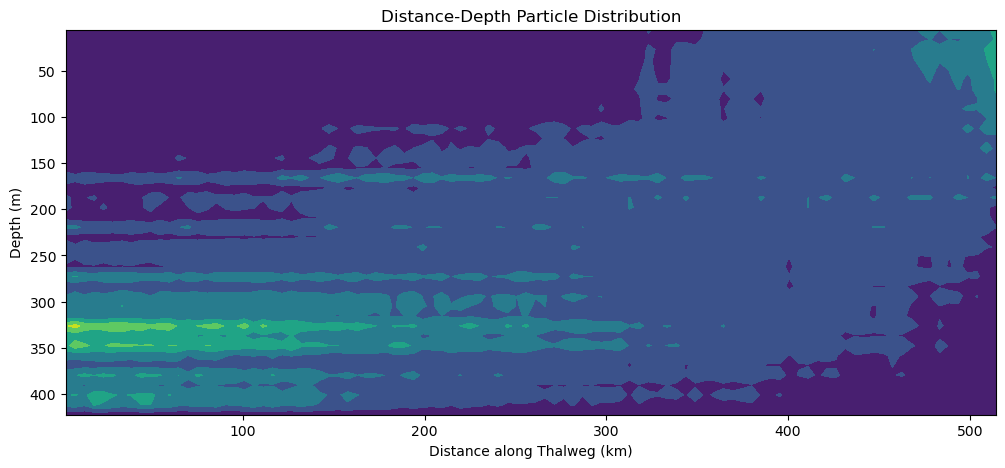

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot the heatmap (transpose to get Depth on Y-axis)
#ds_heatmap.particle_count.T.plot(cmap='Reds', cbar_kwargs={'label': 'Particle Hits'})
plt.contourf(ds_heatmap['distance'], ds_heatmap['depth'], ds_heatmap['particle_count'].T)
# Assuming you have a thalweg_depth array matched to your distance 'd'
# plt.fill_between(thalweg_dist, thalweg_depth, 450, color='lightgrey') 

plt.gca().invert_yaxis()
plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title("Distance-Depth Particle Distribution")
plt.show()

In [ ]:
def create_dist_depth_heatmap(distances, depths, num_dist_bins=100, num_depth_bins=40):
    # Define bin edges
    dist_edges = np.linspace(np.nanmin(distances), np.nanmax(distances), num_dist_bins + 1)
    depth_edges = np.linspace(np.nanmin(depths), np.nanmax(depths), num_depth_bins + 1)
    
    # Calculate centers for coordinates
    dist_centers = (dist_edges[:-1] + dist_edges[1:]) / 2
    depth_centers = (depth_edges[:-1] + depth_edges[1:]) / 2

    # Bin the data (Histogram counts)
    # This replaces the need for a 3D (Depth, Y, X) dataset
    counts, x_edges, y_edges = np.histogram2d(distances, depths, bins=[dist_edges, depth_edges])

    # Create Xarray Dataset
    ds_heat = xr.Dataset(
        {
            "particle_count": (("distance", "depth"), counts)
        },
        coords={
            "distance": dist_centers,
            "depth": depth_centers
        },
        attrs={"description": "Integrated particle counts along channel axis"}
    )
    
    return ds_heat

# Run the function
ds_heatmap = create_dist_depth_heatmap(d, depth_clean)

In [ ]:
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
aa = plt.pcolormesh(ds['Y'], ds['X'], ds['concentration'][-20,:,:],norm=colors.LogNorm(), cmap = cm.solar)
plt.pcolormesh(mask['tmask'][0][0], cmap = cmap)
plt.colorbar(aa)
pylab.plot(thalweg[:,1],thalweg[:,0],color='r')
plt.grid()

In [ ]:
iistart,jjstart = finder2(48.33468910000697, -122.43406932349323, mask=mask)
iiend,jjend = finder2(50.11953151198396, -125.32982172777444, mask=mask)

In [ ]:
jj = [jjstart]
ii = [iistart]
for i in range(iistart+1,iiend,1):
    X = np.argsort(mask.totaldepth[i,:])[::-1]
    jj.append(X[np.where(np.abs(X-jj[-1])<10)[0][0]].item())
    ii.append(i)        
file1 = open("mythalweg.txt", "w") 
for i,it in enumerate(ii):
    file1.write(str(it)+' '+str(jj[i])+'\n')
file1.close() 

In [ ]:
thalweg_V2 = np.loadtxt('my_thalweg.txt', delimiter=' ', dtype=int)

In [ ]:
thalweg.shape

In [ ]:
thalweg_V2.shape

In [ ]:
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)

In [ ]:
plt.pcolormesh(mask['tmask'][0][0], cmap = cmap)
plt.plot(thalweg_V2[:,1],thalweg_V2[:,0],color='r')
plt.grid()

In [ ]:
data_thalweg = data_combined
# 1 year released particles :D

In [ ]:
lon_wat = data_thalweg.where((data_thalweg['status'] > 0) & (data_thalweg['status'] < 4))['lon'].values.flatten()
lat_wat = data_thalweg.where((data_thalweg['status'] > 0) & (data_thalweg['status'] < 4))['lat'].values.flatten()
depth_wat = data_thalweg.where((data_thalweg['status'] > 0) & (data_thalweg['status'] < 4))['z'].values.flatten()

In [ ]:
#lon = data_thalweg.where(data_thalweg['status'] > 0)['lon'].values.flatten()        
#lat = data_thalweg.where(data_thalweg['status'] > 0)['lat'].values.flatten()
#depth = data_thalweg.where(data_thalweg['status'] > 0)['z'].values.flatten()

Maybe try just for particles in the water coumn, not in the sediment...
Then try for the sediment separetly

In [ ]:
ds = particles_amount_dataset_XYDepth(
    lons=lon_wat,
    lats=lat_wat,
    depths=depth_wat,
    num_depth_bins=40,
    mask=mask,
    num_lon=int(len(x)),
    num_lat=int(len(y)))

In [ ]:

aa = plt.pcolormesh(ds['Y'], ds['X'], ds['concentration'][10,:,:],norm=colors.LogNorm(), cmap = cm.solar)
plt.pcolormesh(mask['tmask'][0][0], cmap = cmap)
plt.colorbar(aa)
pylab.plot(thalweg[:,1],thalweg[:,0],color='r')
plt.grid()

In [ ]:
depths = bathy[thalweg[:,0],thalweg[:,1]];
dx=400; dy=500
d = distance(thalweg,dx,dy); d=d/1000;

plt.figure(figsize=(14,6))
pylab.plot(d,-depths[:],color='b')

In [ ]:
offset = 1
mu = ds['concentration'] == 0
conc_thalweg= np.ma.array(ds['concentration'],mask=mu)
caca = conc_thalweg[:,thalweg_V2[:,0]+offset,thalweg_V2[:,1]+offset]

In [ ]:
fig, ax = plt.subplots(1,2,figsize = (15,7), gridspec_kw={'width_ratios': [2, 1]} )
bb = ax[0].contourf(np.arange(0, len(caca[0,:])), ds['Depth'], caca, norm =colors.LogNorm(), cmap = cm.thermal)
ax[0].invert_yaxis()
plt.colorbar(bb)
#
aa = ax[1].pcolormesh(ds['Y'], ds['X'], ds['concentration'][2,:,:],norm=colors.LogNorm(), cmap = cm.solar)
ax[1].pcolormesh(mask['tmask'][0][0], cmap = cmap)
plt.colorbar(aa)
ax[1].plot(thalweg_V2[:,1]+offset,thalweg_V2[:,0]+offset,color='r')
ax[1].grid()

Seems to be a  problem of how my dataset follows the grid that the thalweg is based. Therefore, the shape of the thalweg does not describe what is the actual path to follow for my data... Therefore, there are huge differences and the thalweg plpot does not explains anything...

In [ ]:
from matplotlib import colors
conc_thal=ds['concentration'].values[:,thalweg[:,0],thalweg[:,1]];
XX,ZZ = np.meshgrid(d,-dep[:])

plt.figure(figsize=(19,6))
pylab.pcolormesh(XX,ZZ,conc_thal,norm=colors.LogNorm(),cmap='rainbow')
pylab.colorbar()
#CS=pylab.contour(XX,ZZ,salThalweg,vs, colors='black')

#pylab.clabel(CS, fontsize=9, inline=1)

#pylab.axis(ax)
pylab.xlabel('km')
pylab.ylabel(' z (m)')

In [ ]:
sys.path.append('/ocean/vvalenzuela/MOAD/tools/SalishSeaTools/')

from salishsea_tools import visualisations as vis
from salishsea_tools import (teos_tools, tidetools)

In [ ]:
def artificial_hr(var,Ni,mask):    
    new_conc = np.zeros_like(mask.tmask[0,...],dtype='f')
    for i in range(new_conc.shape[1]-2):
        for j in range(new_conc.shape[2]-2):
            new_conc[:,i,j]=var[:,int(i/Ni),int(j/Ni)]
    return new_conc

In [ ]:
new_conc = artificial_hr(ds['concentration'],4,mask)

In [ ]:
import netCDF4 as nc

In [ ]:
fmesh = nc.Dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
fbathy = nc.Dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_201702.nc')

In [ ]:
thalweg.shape

In [ ]:
unique_vals, unique_indices = np.unique(thalweg[:,0], return_index=True)


In [ ]:
thal = thalweg[unique_indices,:]

In [ ]:
np.savetxt("my_thalweg_01.txt", thal,fmt="%.0f", delimiter=" ")

In [ ]:
ds

Check if better with a different thalweg and/or log scale

In [ ]:
import matplotlib.colors as colors

levels = np.linspace(0, 1000, 40)

fig,ax=plt.subplots(1,1,figsize=(13,4))
cb=vis.contour_thalweg(ax,new_conc,fbathy,fmesh,clevels=levels,cmap=cm.thermal,thalweg_file='my_thalweg.txt', land_colour='Grey')
cb.cmap.set_over('black')
cb.cmap.set_under('lightskyblue')
ax.set_ylim([450,-20])